In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('CarPrice_Assignment.csv')

In [3]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [4]:
df.drop(['car_ID','symboling','enginelocation','boreratio','stroke','compressionratio','citympg','highwaympg','drivewheel','enginetype','fuelsystem','CarName','aspiration','carbody','cylindernumber','wheelbase'],axis=1,inplace=True)

In [5]:
df.head()

,fueltype,doornumber,carlength,carwidth,carheight,curbweight,enginesize,horsepower,peakrpm,price
0,gas,two,168.8,64.1,48.8,2548,130,111,5000,13495.0
1,gas,two,168.8,64.1,48.8,2548,130,111,5000,16500.0
2,gas,two,171.2,65.5,52.4,2823,152,154,5000,16500.0
3,gas,four,176.6,66.2,54.3,2337,109,102,5500,13950.0
4,gas,four,176.6,66.4,54.3,2824,136,115,5500,17450.0


In [6]:
df['doornumber']=np.where(df['doornumber'].str.contains('two'),2,4)

In [7]:
df['fueltype']=np.where(df['fueltype'].str.contains('gas'),0,1)

In [8]:
df

,fueltype,doornumber,carlength,carwidth,carheight,curbweight,enginesize,horsepower,peakrpm,price
0,0,2,168.8,64.1,48.8,2548,130,111,5000,13495.0
1,0,2,168.8,64.1,48.8,2548,130,111,5000,16500.0
2,0,2,171.2,65.5,52.4,2823,152,154,5000,16500.0
3,0,4,176.6,66.2,54.3,2337,109,102,5500,13950.0
4,0,4,176.6,66.4,54.3,2824,136,115,5500,17450.0
...,...,...,...,...,...,...,...,...,...,...
200,0,4,188.8,68.9,55.5,2952,141,114,5400,16845.0
201,0,4,188.8,68.8,55.5,3049,141,160,5300,19045.0
202,0,4,188.8,68.9,55.5,3012,173,134,5500,21485.0
203,1,4,188.8,68.9,55.5,3217,145,106,4800,22470.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fueltype    205 non-null    int64  
 1   doornumber  205 non-null    int64  
 2   carlength   205 non-null    float64
 3   carwidth    205 non-null    float64
 4   carheight   205 non-null    float64
 5   curbweight  205 non-null    int64  
 6   enginesize  205 non-null    int64  
 7   horsepower  205 non-null    int64  
 8   peakrpm     205 non-null    int64  
 9   price       205 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 16.1 KB


In [10]:
df.columns=df.columns.str.capitalize()

In [11]:
df.columns

Index(['Fueltype', 'Doornumber', 'Carlength', 'Carwidth', 'Carheight',
       'Curbweight', 'Enginesize', 'Horsepower', 'Peakrpm', 'Price'],
      dtype='object')

In [12]:
X=df.drop('Price',axis=1)

In [13]:
y=df['Price']

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [15]:
X_train.corr()

,Fueltype,Doornumber,Carlength,Carwidth,Carheight,Curbweight,Enginesize,Horsepower,Peakrpm
Fueltype,1.000000,0.268584,0.224471,0.204556,0.275555,0.185679,0.027384,-0.174653,-0.449616
Doornumber,0.268584,1.000000,0.466742,0.242259,0.578345,0.242297,0.012581,-0.111749,-0.241212
Carlength,0.224471,0.466742,1.000000,0.821267,0.471636,0.868949,0.643460,0.511526,-0.329790
Carwidth,0.204556,0.242259,0.821267,1.000000,0.252645,0.838544,0.710388,0.625418,-0.220357
Carheight,0.275555,0.578345,0.471636,0.252645,1.000000,0.261443,-0.013444,-0.141868,-0.283489
Curbweight,0.185679,0.242297,0.868949,0.838544,0.261443,1.000000,0.841292,0.732840,-0.297485
Enginesize,0.027384,0.012581,0.643460,0.710388,-0.013444,0.841292,1.000000,0.799309,-0.265227
Horsepower,-0.174653,-0.111749,0.511526,0.625418,-0.141868,0.732840,0.799309,1.000000,0.106697
Peakrpm,-0.449616,-0.241212,-0.329790,-0.220357,-0.283489,-0.297485,-0.265227,0.106697,1.000000


<Axes: >

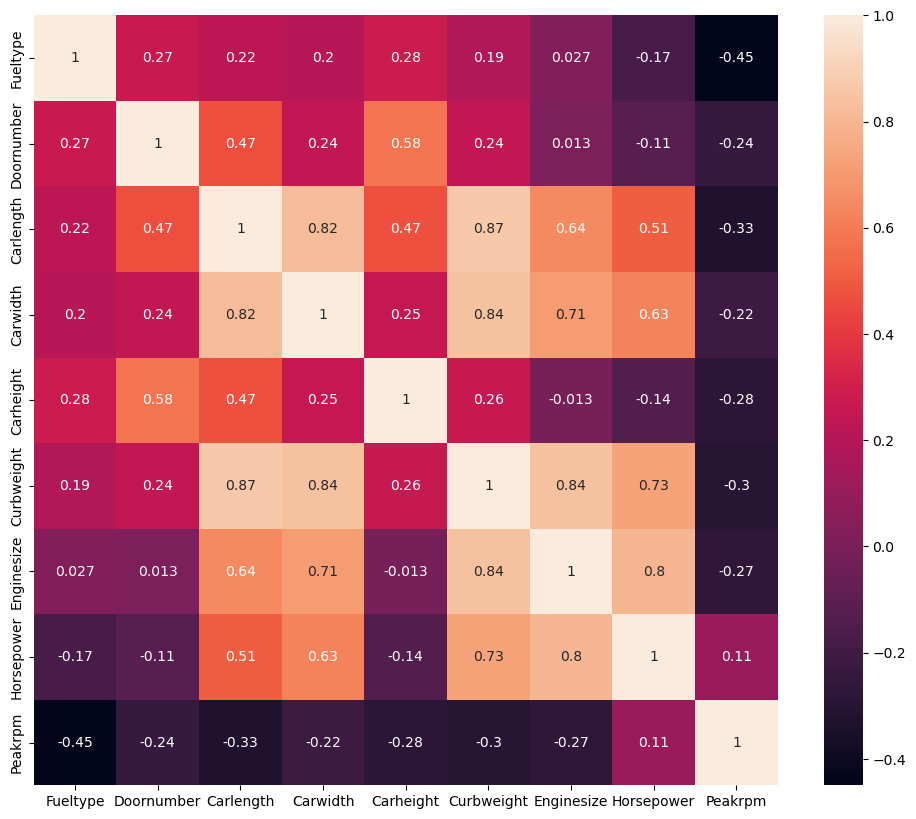

In [16]:
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [17]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
             colname=corr_matrix.columns[i]
             col_corr.add(colname)
    return col_corr

In [18]:
corr_features=correlation(X_train,0.86)

In [31]:
corr_features

{'Curbweight'}

In [19]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [20]:
X_train

,Fueltype,Doornumber,Carlength,Carwidth,Carheight,Enginesize,Horsepower,Peakrpm
177,0,4,175.6,66.5,53.9,122,92,4200
75,0,2,178.4,68.0,54.8,140,175,5000
174,1,4,175.6,66.5,54.9,110,73,4500
31,0,2,144.6,63.9,50.8,92,76,6000
12,0,2,176.8,64.8,54.3,164,121,4250
...,...,...,...,...,...,...,...,...
106,0,2,178.5,67.9,49.7,181,160,5200
14,0,4,189.0,66.9,55.7,164,121,4250
92,0,4,165.3,63.8,54.5,97,69,5200
179,0,2,183.5,67.7,52.0,171,161,5200


In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [22]:
X_train

array([[-0.30265996,  0.88741197,  0.07641283, ..., -0.12142934,
        -0.34075625, -1.96616697],
       [-0.30265996, -1.12687234,  0.30287987, ...,  0.3144969 ,
         1.7237848 , -0.31833179],
       [ 3.30403793,  0.88741197,  0.07641283, ..., -0.41204683,
        -0.81336203, -1.34822878],
       ...,
       [-0.30265996,  0.88741197, -0.75666236, ..., -0.72688245,
        -0.91285799,  0.093627  ],
       [-0.30265996, -1.12687234,  0.71537342, ...,  1.06525876,
         1.37554896,  0.093627  ],
       [-0.30265996,  0.88741197,  0.80434261, ...,  1.30744   ,
         1.15168307,  0.093627  ]])

In [23]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)

Mean absolute error 2651.0041032519543
R2 score 0.8009143919887711


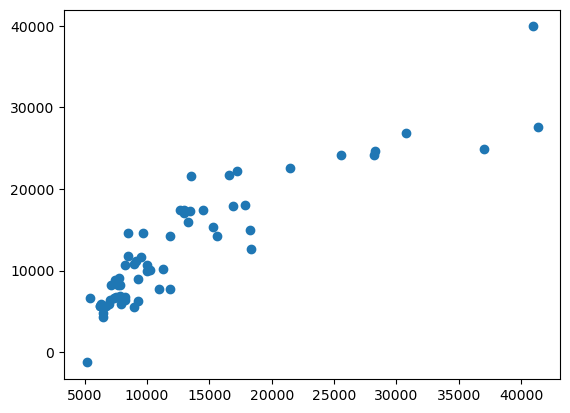

In [24]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

In [25]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train,y_train)
y_pred=ridge.predict(X_test)

Mean absolute error 2656.527105599571
R2 score 0.7999278923031573


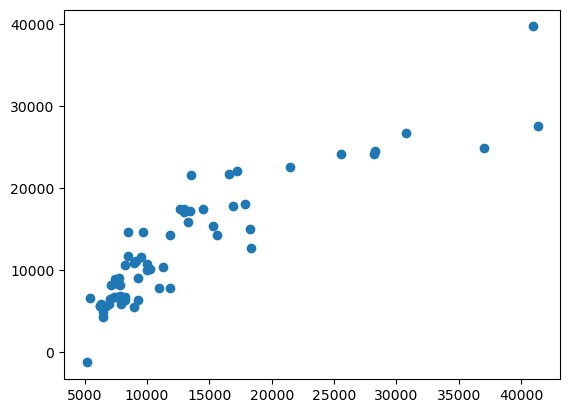

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

Mean absolute error 2650.2900378916615
R2 score 0.8008485182483592


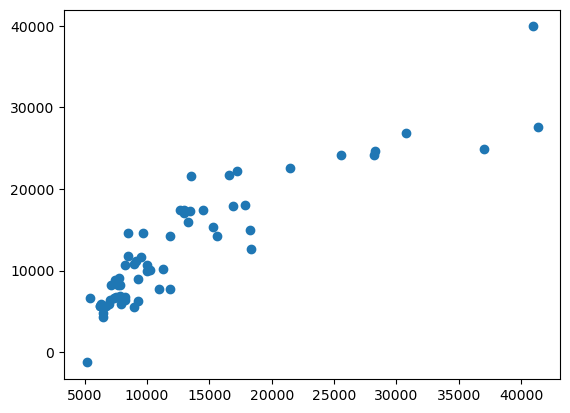

In [27]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train,y_train)  
y_pred=lasso.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

Mean absolute error 2722.45138992498
R2 score 0.7503822222819865


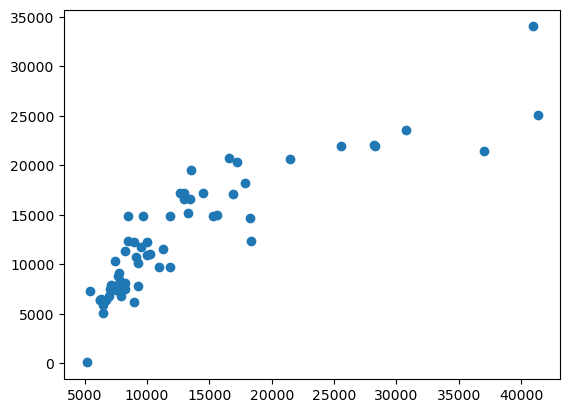

In [28]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elasticnet=ElasticNet()
elasticnet.fit(X_train,y_train)  
y_pred=elasticnet.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

Mean absolute error 2643.1314619555455
R2 score 0.800154199572795


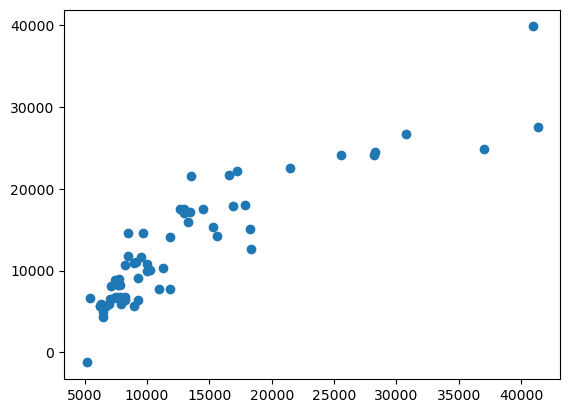

In [32]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train,y_train)
lassocv.predict(X_test)
y_pred=lassocv.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

In [ ]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(lassocv,open('lassocv.pkl','wb'))